In [1]:
# conda activate genomic_tools

import os
import pickle
import pandas as pd
from collections import defaultdict
from matplotlib.backends.backend_pdf import PdfPages

pd.set_option('display.max_columns', None)

In [2]:
# if an event is cell type-specific, and it has a exon_diff_boundary or exon_diff_junction transcript, I need to know if:

# (1) the transcript was emitted and 
# (2) it is also cell type-specific.

# this is important because it means that any overlapping domains of interest are not necessarily cell type-specific.

# to interpret results, I will plot not only the transcript with the event, but also variants of that event.

In [4]:
# # for synthetic skips, need the actual AA sequence that was ultimately translated
# from Bio import SeqIO
# protein_seqs = {record.id: str(record.seq) for record in SeqIO.parse("data/proteins.fa", "fasta")}

In [3]:
with open("data/gencode.v46.annotation_cds_by_transcript.pkl", "rb") as f:
    cds_by_transcript = pickle.load(f)

In [5]:
# Load in event-interproscan results mapping

with open('data/event_interproscan_map.pkl', "rb") as f:
    event_interproscan_map = pickle.load(f)
    
with open("data/signif_event_interproscan_map.pkl", "rb") as f:
    signif_event_interproscan_map = pickle.load(f)
    
with open("data/signif_event_interproscan_summary.pkl", "rb") as f:
    signif_event_interproscan_summary = pickle.load(f)

In [6]:
# # Add gene/protein annotations

# ensembl_info = pd.read_csv("data/gene_descriptions.csv")
# uniprot_info = pd.read_csv("data/gene_uniprot_info.csv")

# gene_info = uniprot_info.merge(ensembl_info, on="gene", how="outer")

# Plot

In [24]:
"""
plot_domain_structure.py  —  v7  (genome-coordinate domain hits, compressed
introns AND compressed "reach" gaps for overlapping domain hits, each shown
as ~100nt of real sequence on either side of a '//' break rather than being
scaled to their true genomic distance)

Two stacked panels per event:
  Top    : genome-coordinate view (exon/intron structure)
  Bottom : domain structure, one row per isoform

X-axis uses a piecewise transform:
  [reach-gap?] -- [left flanking exon CDS] -- //intron// -- [cassette exon]
  -- //intron// -- [right flanking exon CDS] -- [reach-gap?]

Domain hits are drawn directly from precomputed 'genome_coords' (a list of
(genome_start, genome_end) tuples per hit, one tuple per exon segment the
hit touches -- a single hit can be split across an intron).

If a domain hit overlaps the cassette exon but extends past the immediate
flanking exon, the plotted window is widened on that side just enough to
include the hit's full extent -- but the added distance is NOT drawn to
true genomic scale. Instead it's shown as a small fixed-width "reach" gap:
~100nt of real sequence near the flank boundary, a compressed '//' break,
then ~100nt of real sequence approaching the domain hit's far edge. This
keeps the cassette exon and its immediate flanks legible even when a hit
reaches into a much more distant exon.

Inputs: event_interproscan_map, signif_event_interproscan_map,
        cds_by_transcript, ctype
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle, FancyBboxPatch


ANALYSIS_COLORS = {
    'Pfam':             '#4E79A7',
    'SMART':            '#F28E2B',
    'SUPERFAMILY':      '#E15759',
    'CDD':              '#76B7B2',
    'PROSITE profiles': '#59A14F',
    'PROSITE patterns': '#EDC948',
    'Phobius':          '#B07AA1',
    'DeepTMHMM':        '#FF9DA7',
    'CATH-Gene3D':      '#9C755F',
    'CATH-FunFam':      '#BAB0AC',
    'SignalP':          '#D37295',
    'TMbed':            '#E8735A',
    'COILS':            '#A0CBE8',
    'PIRSR':            '#8CD17D',
}
DEFAULT_COLOR = '#bbbbbb'

# fraction of total plot width allocated to each compressed intron
INTRON_FRAC = 0.08

# nt of real sequence shown at each side of a compressed '//' break
GAP_MARGIN_NT = 100

# fraction of a gap's allocated width used for the compressed break itself
# (the remainder is split between the two true-scale margins)
BREAK_FRAC_RATIO = 0.4

# non-DataFrame keys that can appear in event_interproscan_map[ev]
_NON_BUCKET_KEYS = {'meta'}


def _acolor(analysis):
    return ANALYSIS_COLORS.get(analysis, DEFAULT_COLOR)


def _first(df, col, default=None):
    if df is None or (hasattr(df, 'empty') and df.empty):
        return default
    vals = df[col].dropna() if col in df.columns else pd.Series(dtype=object)
    return vals.iloc[0] if not vals.empty else default


def _is_nan(v):
    """Check for None or float NaN."""
    return v is None or (isinstance(v, float) and v != v)


def _bucket_frames(ipr_rec):
    """Yield (bucket_key, df) pairs from ipr_rec, skipping 'meta' and non-DataFrame / empty entries."""
    for k, v in ipr_rec.items():
        if k in _NON_BUCKET_KEYS:
            continue
        if v is None or not hasattr(v, 'columns'):
            continue
        if hasattr(v, 'empty') and v.empty:
            continue
        yield k, v


# signature_description variants that should be treated as one label for
# grouping/collapsing purposes, regardless of order or which combination
# appears (e.g. 'NP_BIND | BINDING', 'BINDING | NP_BIND', and plain
# 'BINDING' all mean the same thing for display purposes here)
_LABEL_SYNONYM_GROUPS = [
    {'BINDING', 'NP_BIND'},
]


def _normalize_signature_label(desc):
    """
    Canonicalize a signature_description for grouping. A pipe-joined label
    whose parts are all members of one of _LABEL_SYNONYM_GROUPS collapses to
    that group's first (canonical) member. Anything else is left as-is.
    """
    if not isinstance(desc, str):
        return desc
    parts = {p.strip() for p in desc.split('|') if p.strip()}
    if not parts:
        return desc
    for group in _LABEL_SYNONYM_GROUPS:
        if parts <= group:
            return next(iter(sorted(group)))
    return desc


def _collapse_repeated_hits(df):
    """
    Merge rows that share the same (analysis, normalized signature label)
    into a single representative row whose genome_coords is the union of
    every group member's segments (merged where overlapping or adjacent).

    Some analyses (PIRSR especially) emit one row per individual residue-
    level site -- e.g. many separate 'BINDING', 'NP_BIND', 'NP_BIND |
    BINDING' rows each covering just a residue or two -- which otherwise
    each get their own track via _pack_tracks. Collapsing them here shows
    one track per unique (normalized) label, covering every region that
    label actually touches, instead of a stack of near-duplicate tracks.
    See _normalize_signature_label for which labels are treated as
    synonyms (currently just BINDING/NP_BIND combinations).

    Rows with analysis == 'PIRSR' and a missing/NaN signature_description
    are dropped entirely (they render as a literal 'nan' label and carry no
    useful information).

    Rows with a genuinely different (normalized) label are never merged,
    so distinct domains/regions stay on separate tracks.
    """
    if df is None or (hasattr(df, 'empty') and df.empty):
        return df
    if 'genome_coords' not in df.columns:
        return df

    if 'analysis' in df.columns and 'signature_description' in df.columns:
        is_nan_pirsr = (df['analysis'] == 'PIRSR') & df['signature_description'].isna()
        df = df.loc[~is_nan_pirsr]
        if df.empty:
            return df

    key_cols = [c for c in ('analysis', 'signature_description') if c in df.columns]
    if not key_cols:
        return df

    df = df.copy()
    if 'signature_description' in df.columns:
        df['_norm_label'] = df['signature_description'].map(_normalize_signature_label)
        group_cols = [c if c != 'signature_description' else '_norm_label' for c in key_cols]
    else:
        group_cols = key_cols

    out_rows = []
    for _, group in df.groupby(group_cols, dropna=False, sort=False):
        if len(group) == 1:
            rep = group.iloc[0].to_dict()
            rep.pop('_norm_label', None)
            out_rows.append(rep)
            continue
        all_segs = []
        for _, row in group.iterrows():
            coords = _valid_genome_coords(row.get('genome_coords'))
            if coords:
                all_segs.extend((min(s, e), max(s, e)) for s, e in coords)
        if not all_segs:
            rep = group.iloc[0].to_dict()
            rep.pop('_norm_label', None)
            out_rows.append(rep)
            continue
        all_segs.sort()
        merged = []
        for s, e in all_segs:
            if merged and s <= merged[-1][1] + 1:
                merged[-1] = (merged[-1][0], max(merged[-1][1], e))
            else:
                merged.append((s, e))
        rep = group.iloc[0].to_dict()
        rep['genome_coords'] = merged
        if 'signature_description' in rep:
            rep['signature_description'] = group['_norm_label'].iloc[0]
        rep.pop('_norm_label', None)
        if 'aa_start' in group.columns:
            rep['aa_start'] = group['aa_start'].min()
        if 'aa_end' in group.columns:
            rep['aa_end'] = group['aa_end'].max()
        out_rows.append(rep)

    return pd.DataFrame(out_rows).reset_index(drop=True)


def _valid_genome_coords(coords):
    """Return coords if it's a usable list of (start, end) tuples, else None."""
    if coords is None:
        return None
    if isinstance(coords, float):  # NaN
        return None
    if not isinstance(coords, (list, tuple)) or len(coords) == 0:
        return None
    return coords


def _cds_rows_sorted(cds_obj, strand):
    """Return CDS rows as list of dicts, sorted in translation order."""
    if cds_obj is None:
        return []
    if hasattr(cds_obj, 'iterrows'):
        rows = [{'start': int(r['start']), 'end': int(r['end'])}
                for _, r in cds_obj.iterrows()]
    else:
        rows = [{'start': int(c['start']), 'end': int(c['end'])} for c in cds_obj]
    return sorted(rows, key=lambda r: r['start'],
                  reverse=(strand == '-'))


def _build_rel_to_genome(cds_rows):
    """
    Build a cumulative relative-CDS-position -> genomic-position map from
    CDS exon rows already in translation order (e.g. from _cds_rows_sorted,
    with the cassette exon excluded for a skip transcript).

    Each entry's rel_start/rel_end is 0-indexed and cumulative across exons
    in translation order. genome_start/genome_end are always genomic-
    ascending (genome_start <= genome_end) regardless of strand --
    _map_aa_to_genome handles the strand-dependent direction itself.
    """
    rel_to_genome = []
    offset = 0
    for row in cds_rows:
        length = row['end'] - row['start'] + 1
        rel_to_genome.append({
            'rel_start': offset,
            'rel_end': offset + length - 1,
            'genome_start': row['start'],
            'genome_end': row['end'],
        })
        offset += length
    return rel_to_genome


def _map_aa_to_genome(rel_to_genome, aa_start, aa_end, strand):
    """
    Map a 1-indexed, inclusive amino-acid range [aa_start, aa_end] to
    genomic coordinates, using a rel_to_genome map built by
    _build_rel_to_genome. Correctly splits a range across an exon boundary
    (returns one segment per exon touched) and handles '-' strand, where
    increasing relative/transcript position corresponds to decreasing
    genomic position.

    If the AA range extends past what rel_to_genome covers, the returned
    segments simply stop where the coverage runs out (no error) -- callers
    that need to know whether that happened should compare how much of
    (aa_end - aa_start + 1) * 3 nt worth of segments came back.
    """
    result = []
    cds_start = (aa_start - 1) * 3
    cds_end = (aa_end - 1) * 3 + 2
    for seg in rel_to_genome:
        overlap_start = max(cds_start, seg['rel_start'])
        overlap_end = min(cds_end, seg['rel_end'])
        if overlap_start <= overlap_end:
            if strand == '-':
                g_start = seg['genome_end'] - (overlap_end - seg['rel_start'])
                g_end = seg['genome_end'] - (overlap_start - seg['rel_start'])
            else:
                g_start = seg['genome_start'] + (overlap_start - seg['rel_start'])
                g_end = seg['genome_start'] + (overlap_end - seg['rel_start'])
            result.append((g_start, g_end))
    return result


def _flanking_exon_extents(transcript, exon_cds_start, exon_cds_end,
                           strand, cds_by_transcript):
    """
    Return (upstream_cds_start, upstream_cds_end,
            downstream_cds_start, downstream_cds_end)
    for the exons immediately flanking the cassette exon in the given transcript.
    Returns None for a flank if the cassette exon is terminal.
    """
    rows = _cds_rows_sorted(cds_by_transcript.get(transcript), strand)
    if not rows:
        return None, None, None, None

    # find the CDS row(s) that correspond to the cassette exon
    cassette_idx = None
    for i, r in enumerate(rows):
        if r['start'] == exon_cds_start and r['end'] == exon_cds_end:
            cassette_idx = i
            break
        # partially overlapping (partially_coding case)
        if r['start'] <= exon_cds_end and r['end'] >= exon_cds_start:
            cassette_idx = i
            break

    if cassette_idx is None:
        return None, None, None, None

    up_row   = rows[cassette_idx - 1] if cassette_idx > 0 else None
    down_row = rows[cassette_idx + 1] if cassette_idx < len(rows) - 1 else None

    up_s   = up_row['start']   if up_row   else None
    up_e   = up_row['end']     if up_row   else None
    dn_s   = down_row['start'] if down_row else None
    dn_e   = down_row['end']   if down_row else None

    return up_s, up_e, dn_s, dn_e


def _gap_segments(g_lo, g_hi, total_frac):
    """
    Build sub-segments spanning [g_lo, g_hi] (g_lo < g_hi) that together
    occupy total_frac of the plot width.

    Long gaps (introns, or the "reach" to a distant overlapping domain hit)
    are split into:
      [true-scale margin, ~GAP_MARGIN_NT] -- [compressed break] -- [true-scale margin, ~GAP_MARGIN_NT]
    so the plot shows real sequence near each boundary rather than scaling
    the entire (possibly huge) genomic distance linearly.

    Short gaps (<= 2x margin) are drawn as a single proportional,
    uncompressed segment.

    Returns a list of (g_s, g_e, frac, kind) tuples in genomic-ascending
    order, kind in {'plain', 'break'}.
    """
    span = g_hi - g_lo
    if span <= 2 * GAP_MARGIN_NT or total_frac <= 0:
        return [(g_lo, g_hi, total_frac, 'plain')]
    margin_frac = total_frac * (1 - BREAK_FRAC_RATIO) / 2
    break_frac  = total_frac * BREAK_FRAC_RATIO
    return [
        (g_lo,                  g_lo + GAP_MARGIN_NT, margin_frac, 'plain'),
        (g_lo + GAP_MARGIN_NT,  g_hi - GAP_MARGIN_NT, break_frac,  'break'),
        (g_hi - GAP_MARGIN_NT,  g_hi,                 margin_frac, 'plain'),
    ]


# ── piecewise coordinate transform ────────────────────────────────────────
class PiecewiseTransform:
    """
    Maps genomic coordinates to plot x using a piecewise linear transform.

    Segments (in left-to-right plot order, genomic-ascending before any
    strand flip): [(g_start, g_end, plot_frac, kind), ...]
    plot_frac is the fraction of total plot width this segment occupies.
    kind is 'plain' or 'break' (a compressed '//' zone).

    For minus-strand genes, genomic coordinates are reversed before applying
    the transform (so transcription 5'->3' always maps left->right).
    """
    def __init__(self, segments, total_width=1000.0, strand='+'):
        self.strand      = strand
        self.total_width = total_width
        # normalize to 4-tuples (older 3-tuple callers default to 'plain')
        norm = [(s[0], s[1], s[2], s[3] if len(s) > 3 else 'plain') for s in segments]
        # for minus strand, reverse segment order and flip coordinates
        if strand == '-':
            norm = [(g_e, g_s, frac, kind) for g_s, g_e, frac, kind in reversed(norm)]
        self.segments = norm
        # precompute cumulative plot positions
        self.seg_px = []
        x = 0.0
        for g_s, g_e, frac, kind in norm:
            w = frac * total_width
            self.seg_px.append((x, x + w))
            x += w

    def __call__(self, g_pos):
        """Map a single genomic position to plot x."""
        for i, (g_s, g_e, frac, kind) in enumerate(self.segments):
            px_s, px_e = self.seg_px[i]
            lo, hi = min(g_s, g_e), max(g_s, g_e)
            if lo <= g_pos <= hi:
                # NOTE: g_e - g_s can be negative here (segments are stored
                # reversed for '-' strand), so this must NOT be clamped to a
                # minimum of 1 like a same-sign-only case would suggest --
                # doing so previously destroyed the sign for reversed
                # segments and sent t (and the resulting pixel position)
                # blowing up to the raw genomic coordinate delta. Only guard
                # against true zero-width segments.
                denom = g_e - g_s
                t = (g_pos - g_s) / denom if denom != 0 else 0.0
                return px_s + t * (px_e - px_s)
        # outside all segments — clamp
        if g_pos < min(self.segments[0][0], self.segments[0][1]):
            return self.seg_px[0][0]
        return self.seg_px[-1][1]

    @property
    def break_zones(self):
        """Return list of (px_start, px_end) for compressed '//' break segments."""
        return [self.seg_px[i] for i, (_, _, _, kind) in enumerate(self.segments)
                if kind == 'break']

    @property
    def compressed_zones(self):
        """Backward-compatible alias for break_zones."""
        return self.break_zones


def _build_transform(exon_cds_start, exon_cds_end, strand,
                     up_s, up_e, dn_s, dn_e, total_width=1000.0,
                     domain_min_g=None, domain_max_g=None):
    """
    Build the piecewise transform given cassette exon and flanking exon extents.

    domain_min_g / domain_max_g (optional): absolute genomic coordinates
    (genomic-ascending, regardless of strand) that must be included in the
    plotted window -- the full extent of a domain hit that overlaps the
    cassette exon but spills past the immediate flanking exon. When given,
    the window is widened on that side via a compressed "reach" gap (see
    _gap_segments) rather than by scaling the true distance proportionally
    -- so an overlapping hit far away doesn't crush the cassette exon down
    to an unreadable sliver.

    Returns (PiecewiseTransform, g_left, g_right).
    """
    # genomic-left flank pair and genomic-right flank pair, independent of
    # translation direction (up/down) -- for '+' strand, up = genomic-left;
    # for '-' strand, up = genomic-right.
    if strand == '+':
        if up_s is not None:
            gl_s, gl_e, has_gl = up_s, up_e, True
        else:
            gl_s, gl_e, has_gl = exon_cds_start - 10, exon_cds_start - 1, False
        if dn_s is not None:
            gr_s, gr_e, has_gr = dn_s, dn_e, True
        else:
            gr_s, gr_e, has_gr = exon_cds_end + 1, exon_cds_end + 10, False
    else:
        if dn_s is not None:
            gl_s, gl_e, has_gl = dn_s, dn_e, True
        else:
            gl_s, gl_e, has_gl = exon_cds_start - 10, exon_cds_start - 1, False
        if up_s is not None:
            gr_s, gr_e, has_gr = up_s, up_e, True
        else:
            gr_s, gr_e, has_gr = exon_cds_end + 1, exon_cds_end + 10, False

    # does an overlapping domain hit reach past the immediate flank?
    needs_ext_left  = domain_min_g is not None and domain_min_g < min(gl_s, gl_e)
    needs_ext_right = domain_max_g is not None and domain_max_g > max(gr_s, gr_e)

    g_left  = min(gl_s, gl_e, exon_cds_start, exon_cds_end,
                  domain_min_g if needs_ext_left else min(gl_s, gl_e))
    g_right = max(gr_s, gr_e, exon_cds_start, exon_cds_end,
                  domain_max_g if needs_ext_right else max(gr_s, gr_e))

    n_introns = has_gl + has_gr
    n_ext     = needs_ext_left + needs_ext_right
    ext_frac  = INTRON_FRAC * 0.8
    intron_total = n_introns * INTRON_FRAC
    ext_total    = n_ext * ext_frac
    coding_total = max(1.0 - intron_total - ext_total, 0.2)

    # split coding_total among left flank, cassette, right flank
    left_width  = abs(gl_e - gl_s)
    exon_width  = abs(exon_cds_end - exon_cds_start)
    right_width = abs(gr_e - gr_s)
    total_coding_nt = left_width + exon_width + right_width or 1

    left_frac  = coding_total * left_width  / total_coding_nt
    exon_frac  = coding_total * exon_width  / total_coding_nt
    right_frac = coding_total * right_width / total_coding_nt

    # build in genomic-ascending order; PiecewiseTransform reverses for '-' strand
    segments = []
    if needs_ext_left:
        segments += _gap_segments(domain_min_g, min(gl_s, gl_e), ext_frac)
    if has_gl:
        segments.append((gl_s, gl_e, left_frac, 'plain'))
        segments += _gap_segments(gl_e, exon_cds_start, INTRON_FRAC)
    segments.append((exon_cds_start, exon_cds_end, exon_frac, 'plain'))
    if has_gr:
        segments += _gap_segments(exon_cds_end, gr_s, INTRON_FRAC)
        segments.append((gr_s, gr_e, right_frac, 'plain'))
    if needs_ext_right:
        segments += _gap_segments(max(gr_s, gr_e), domain_max_g, ext_frac)

    tfm = PiecewiseTransform(segments, total_width=total_width, strand=strand)
    return tfm, g_left, g_right


# ── domain track drawing ───────────────────────────────────────────────────
def _pack_tracks(intervals, max_tracks=4):
    intervals = sorted(intervals, key=lambda x: x[0])
    tracks = []
    row_to_track = {}
    for s, e, idx in intervals:
        placed = False
        for ti, track in enumerate(tracks):
            if track < s:
                tracks[ti] = e
                row_to_track[idx] = ti
                placed = True
                break
        if not placed and len(tracks) < max_tracks:
            tracks.append(e)
            row_to_track[idx] = len(tracks) - 1
    return row_to_track


def _aa_to_genomic(aa_pos, aa_ref, cds_start, cds_end, strand):
    """Approximate genomic position for a single AA point (used only for
    the truncation/frameshift marker, which has no genome_coords segments)."""
    nt_offset = (aa_pos - aa_ref) * 3
    if strand == '+':
        return cds_start + nt_offset
    else:
        return cds_end - nt_offset


def _clip_segments_to_view(coords, g_left, g_right):
    """
    Keep only the portion of each (genome_start, genome_end) segment that
    falls within [g_left, g_right] (the plotted genomic window). Segments
    entirely outside the window are dropped; segments that partially overlap
    are trimmed to the visible portion.

    Note: g_left/g_right already account for any widening done in
    _build_transform to accommodate overlapping domain hits, so a hit that
    overlaps the cassette exon will normally fall entirely inside the
    window here and won't actually get clipped. Hits that don't overlap the
    cassette exon (e.g. in a more distant exon of another isoform) are
    unaffected by the widening and are still clipped as before.
    """
    if coords is None:
        return None
    kept = []
    for s, e in coords:
        lo, hi = min(s, e), max(s, e)
        clipped_lo = max(lo, g_left)
        clipped_hi = min(hi, g_right)
        if clipped_lo <= clipped_hi:
            kept.append((clipped_lo, clipped_hi))
    return kept if kept else None


def _all_flank_extent(buckets):
    """
    Return (min_g, max_g) across every bucket's OWN flanking-exon extents
    (up_s/up_e/dn_s/dn_e), the outer genomic bounds of every isoform's
    real, known neighboring exon, not just the inclusion transcript's --
    plus, for skip buckets, their full_exon_rows (the complete inclusion
    exon structure minus cassette) and translated_segments (how far
    translation actually reached).

    Needed because each isoform row now draws its own flank (see
    _flanking_exon_extents calls in the bucket-assembly loop): if a
    sibling's real flank -- or a skip bucket's full exon structure --
    reaches further out than whatever a domain hit alone would have
    justified widening the shared window to, that coordinate falls outside
    the transform's covered range and gets clamped to the same edge pixel
    by PiecewiseTransform, collapsing the box to zero width. Folding all of
    this into the widening calculation (alongside _overlapping_domain_extent)
    prevents that.

    Returns (None, None) if no bucket has any known extent.
    """
    coords = []
    for b in buckets:
        for key in ('up_s', 'up_e', 'dn_s', 'dn_e'):
            v = b.get(key)
            if v is not None:
                coords.append(v)
        for row in (b.get('full_exon_rows') or []):
            coords.append(row['start'])
            coords.append(row['end'])
        for s, e in (b.get('translated_segments') or []):
            coords.append(s)
            coords.append(e)
    if not coords:
        return None, None
    return min(coords), max(coords)


def _touched_exon_px_ranges(buckets, tfm, g_left, g_right):
    """
    Collect merged pixel ranges for every exon segment touched by any
    bucket's domain hits (via genome_coords), clipped to the plotted
    window and mapped through tfm. Pooled across all buckets since the
    top schematic isn't isoform-specific.

    Used to mark real exonic sequence in the top panel beyond the
    immediate flanking exon -- we don't know the true splice boundaries
    that far out, but we do know a domain hit's exact segment coordinates,
    so this keeps the top panel from looking like bare intron when there's
    actually a distant exon under a domain annotation shown below.
    """
    all_px = []
    for b in buckets:
        df = b.get('domains')
        if df is None or not hasattr(df, 'columns') or df.empty:
            continue
        if 'genome_coords' not in df.columns:
            continue
        for _, row in df.iterrows():
            coords = _valid_genome_coords(row.get('genome_coords'))
            coords = _clip_segments_to_view(coords, g_left, g_right)
            if not coords:
                continue
            for g_s, g_e in coords:
                px_s, px_e = tfm(min(g_s, g_e)), tfm(max(g_s, g_e))
                all_px.append((min(px_s, px_e), max(px_s, px_e)))
    all_px.sort()
    merged = []
    for px_s, px_e in all_px:
        if merged and px_s <= merged[-1][1] + 0.5:
            merged[-1] = (merged[-1][0], max(merged[-1][1], px_e))
        else:
            merged.append((px_s, px_e))
    return merged


def _overlapping_domain_extent(buckets, exon_start, exon_end):
    """
    Scan every bucket's domain hits for any hit that overlaps the cassette
    exon [exon_start, exon_end] (checking each of its genome_coords segments
    individually, not just its bounding box). For every such hit, fold its
    FULL genomic extent (across all its segments, including any that fall
    in more distant exons) into a running (min_g, max_g).

    This tells _build_transform how far the plotted window needs to reach
    so the most expansive overlapping hit -- across all isoform panels,
    since they share one transform -- is drawn whole rather than clipped.

    Returns (None, None) if nothing overlaps the cassette exon.
    """
    exon_lo, exon_hi = min(exon_start, exon_end), max(exon_start, exon_end)
    min_g, max_g = None, None
    for b in buckets:
        df = b.get('domains')
        if df is None or not hasattr(df, 'columns') or df.empty:
            continue
        if 'genome_coords' not in df.columns:
            continue
        for _, row in df.iterrows():
            coords = _valid_genome_coords(row.get('genome_coords'))
            if not coords:
                continue
            # does any individual segment actually touch the cassette exon?
            touches_exon = any(
                min(s, e) <= exon_hi and max(s, e) >= exon_lo
                for s, e in coords
            )
            if not touches_exon:
                continue
            flat = [c for pair in coords for c in pair]
            hit_lo, hit_hi = min(flat), max(flat)
            min_g = hit_lo if min_g is None else min(min_g, hit_lo)
            max_g = hit_hi if max_g is None else max(max_g, hit_hi)
    return min_g, max_g


def _draw_domains(ax, df, tfm, y_center, g_left, g_right,
                  direction=1, track_h=0.22,
                  gap=0.08, max_tracks=4, alpha=0.85, label_fontsize=7,
                  connector_lw=0.6):
    """
    Draw one row per domain hit, using precomputed genomic coordinates.

    df must have a 'genome_coords' column: for each row, a list of
    (genome_start, genome_end) tuples -- one tuple per exon segment the
    hit touches. A hit split across an intron produces >1 tuple and is
    drawn as multiple boxes joined by a thin connector line.

    Only the portion of each hit that falls within [g_left, g_right] is
    drawn. g_left/g_right are the (possibly widened) plotted genomic
    window computed in _build_transform -- a hit overlapping the cassette
    exon is included in full there, so it won't be clipped here; hits
    elsewhere that don't overlap the cassette exon are still clipped out
    rather than distorting the local view.
    """
    if df is None or (hasattr(df, 'empty') and df.empty):
        return y_center
    if 'genome_coords' not in df.columns:
        return y_center

    df = df.reset_index(drop=True)

    intervals = []       # (overall_px_start, overall_px_end, row_idx) for track packing
    row_segments = {}    # row_idx -> sorted list of (px_start, px_end)

    for i, row in df.iterrows():
        coords = _valid_genome_coords(row.get('genome_coords'))
        coords = _clip_segments_to_view(coords, g_left, g_right)
        if coords is None:
            continue
        segs_px = []
        for g_s, g_e in coords:
            px_s, px_e = tfm(min(g_s, g_e)), tfm(max(g_s, g_e))
            segs_px.append((min(px_s, px_e), max(px_s, px_e)))
        if not segs_px:
            continue
        segs_px.sort()
        row_segments[i] = segs_px
        intervals.append((segs_px[0][0], segs_px[-1][1], i))

    # shade every exon segment actually touched by a domain hit -- not just
    # the immediate flank (handled separately, per-bucket, in the caller).
    # This covers the general case: a hit's genome_coords can land in a
    # more distant exon (e.g. two exons out) that isn't anyone's immediate
    # neighbor, and that's still real exonic sequence worth marking.
    # Ranges are merged first so overlapping hits (e.g. Phobius + TMbed on
    # the same exon) don't stack shading into a visibly darker seam.
    all_px_ranges = sorted(
        px_range for segs in row_segments.values() for px_range in segs
    )
    merged = []
    for px_s, px_e in all_px_ranges:
        if merged and px_s <= merged[-1][1] + 0.5:
            merged[-1] = (merged[-1][0], max(merged[-1][1], px_e))
        else:
            merged.append((px_s, px_e))
    for px_s, px_e in merged:
        ax.axvspan(px_s, px_e, color='#ececec', zorder=0, alpha=0.9)

    row_to_track = _pack_tracks(intervals, max_tracks=max_tracks)

    for overall_s, overall_e, i in intervals:
        ti = row_to_track.get(i)
        if ti is None:
            continue
        row = df.iloc[i]
        y = y_center + direction * (gap + ti * (track_h + 0.45) + track_h / 2)
        color = _acolor(row.get('analysis', ''))
        segs_px = row_segments[i]

        # thin connector line across the full hit when it's split by intron(s)
        if len(segs_px) > 1:
            ax.plot([overall_s, overall_e], [y, y],
                    color=color, lw=connector_lw, alpha=alpha * 0.6,
                    zorder=3, solid_capstyle='butt')

        # one box per genomic segment
        for px_s, px_e in segs_px:
            w = max(px_e - px_s, 1)
            ax.add_patch(FancyBboxPatch(
                (px_s, y - track_h / 2), w, track_h,
                boxstyle='round,pad=0.3',
                facecolor=color, edgecolor='none',
                alpha=alpha, zorder=4
            ))

        label = str(row.get('signature_description') or
                    row.get('interpro_description') or '')
        total_w = overall_e - overall_s
        if label and label.strip('-').strip() and total_w > 15:
            short = label[:40] + '…' if len(label) > 40 else label
            ax.text(overall_s + total_w / 2, y, short,
                    ha='center', va='center',
                    fontsize=label_fontsize,
                    color='#333333', fontweight='bold',
                    zorder=6, clip_on=True)

    max_y = max(
        (y_center + direction * (gap + ti * (track_h + 0.45) + track_h / 2)
         for ti in row_to_track.values()),
        default=y_center
    )
    return max_y


# ── helpers ────────────────────────────────────────────────────────────────
def _draw_compression_shading(ax, tfm, line_y=0.0, mark_fontsize=7, suppress_ranges=None):
    """
    Mark each compressed '//' break zone (long introns, or the "reach" gap
    to a distant overlapping domain hit) with a small '//' label centered
    on the intron/backbone line (at data y = line_y). No shading -- just
    the break mark itself.

    suppress_ranges (optional): list of (px_s, px_e) ranges -- typically the
    real exonic segments actually touched by domain hits (see
    _touched_exon_px_ranges) -- for which the '//' mark is skipped. A break
    zone is meant to read as "compressed intron/unknown sequence", so if a
    domain hit's real exon segment lands inside it, showing '//' there would
    misleadingly suggest that stretch is intronic when it's actually known
    exonic sequence, just heavily compressed.
    """
    suppress_ranges = suppress_ranges or []
    for px_s, px_e in tfm.break_zones:
        overlaps = any(not (r_e < px_s or r_s > px_e) for r_s, r_e in suppress_ranges)
        if overlaps:
            continue
        cx = (px_s + px_e) / 2
        ax.text(cx, line_y, '/ /', ha='center', va='center',
                fontsize=mark_fontsize, color='#888888',
                fontweight='bold', zorder=5,
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor='none', alpha=0.85))


def _get_gene_name(ev, signif_event_interproscan_map, ctype):
    for ct in ([ctype] + [c for c in signif_event_interproscan_map if c != ctype]):
        df = signif_event_interproscan_map.get(ct)
        if df is None:
            continue
        rows = df[df['event_id'] == ev]
        if not rows.empty and 'Gene' in rows.columns:
            val = rows['Gene'].dropna()
            if not val.empty:
                return str(val.iloc[0])
    return ''


def _get_ctype_annotation(ev, transcript, bucket,
                          signif_event_interproscan_map, ctype):
    """
    r is a per-event property (exon PSI correlation with cell type abundance),
    not per-transcript. Look up by event_id only across all cell types.
    """
    r = is_specific = None
    other_ctypes = []

    def _lookup(df):
        if df is None:
            return None, None
        rows = df[df['event_id'] == ev]
        if not rows.empty:
            return rows['r'].iloc[0], rows['is_specific'].iloc[0]
        return None, None

    r, is_specific = _lookup(signif_event_interproscan_map.get(ctype))

    for ct, df in signif_event_interproscan_map.items():
        if ct == ctype:
            continue
        ct_r, _ = _lookup(df)
        if ct_r is not None:
            other_ctypes.append((ct, ct_r))

    return r, is_specific, other_ctypes


# ── main entry point ────────────────────────────────────────────────────────
def plot_event_domains(ev, event_interproscan_map, signif_event_interproscan_map,
                       cds_by_transcript, ctype,
                       intron_frac=INTRON_FRAC, gap_margin_nt=GAP_MARGIN_NT,
                       fontscale=1.0,
                       figsize=None, save_path=None, dpi=150):
    """
    Parameters
    ----------
    ev                            : event ID
    event_interproscan_map        : dict  ev -> {bucket: DataFrame, 'meta': dict}
    signif_event_interproscan_map : dict  ctype -> long-form DataFrame
    cds_by_transcript             : dict  transcript_id -> CDS DataFrame/list
    ctype                         : focal cell type
    intron_frac                   : fraction of plot width per compressed intron/gap
    gap_margin_nt                 : nt of real sequence shown at each side of a
                                     compressed '//' break (introns and domain-reach gaps)
    figsize / save_path / dpi     : matplotlib args
    """
    global INTRON_FRAC, GAP_MARGIN_NT
    INTRON_FRAC = intron_frac
    GAP_MARGIN_NT = gap_margin_nt

    # scale all font sizes
    base = 6.0 * fontscale
    plt.rcParams.update({
        'font.size':        base,
        'axes.titlesize':   base * 1.1,
        'axes.labelsize':   base,
        'xtick.labelsize':  base * 0.9,
        'ytick.labelsize':  base * 0.9,
        'legend.fontsize':  base * 0.9,
    })

    ipr_rec = event_interproscan_map.get(ev, {})
    incl_df = ipr_rec.get('inclusion')
    if incl_df is None or incl_df.empty:
        print(f"{ev}: no inclusion data")
        return None

    aa_start  = _first(incl_df, 'aa_start')
    aa_end    = _first(incl_df, 'aa_end')
    cds_start = int(_first(incl_df, 'exon_cds_start', 0))
    cds_end   = int(_first(incl_df, 'exon_cds_end',   0))
    incl_t    = _first(incl_df, 'protein_accession', '')
    gene_name = _get_gene_name(ev, signif_event_interproscan_map, ctype)

    # chrom and strand from signif_event_interproscan_map
    chrom  = ''
    strand = '+'
    for ct_df in signif_event_interproscan_map.values():
        if ct_df is None:
            continue
        rows = ct_df[ct_df['event_id'] == ev]
        if not rows.empty:
            if 'chr' in ct_df.columns:
                chrom = str(rows['chr'].iloc[0])
            if 'strand' in ct_df.columns:
                strand = str(rows['strand'].iloc[0])
            break
    # fallback to inclusion df
    if not chrom:
        chrom  = _first(incl_df, 'chrom', '')
    if strand == '+':
        strand = _first(incl_df, 'strand', '+')

    # get flanking exon extents from inclusion transcript
    up_s, up_e, dn_s, dn_e = _flanking_exon_extents(
        incl_t, cds_start, cds_end, strand, cds_by_transcript
    )

    # full exon structure of the inclusion transcript, minus the cassette
    # exon -- this IS what a skip transcript's exon structure is by
    # definition (real or synthetic), so skip buckets draw every one of
    # these rather than just the immediate flank. Also used to map a skip
    # transcript's translated AA length back to genomic coordinates.
    incl_cds_rows = _cds_rows_sorted(cds_by_transcript.get(incl_t), strand)
    incl_rows_no_cassette = [
        r for r in incl_cds_rows
        if not (r['start'] == cds_start and r['end'] == cds_end)
    ]
    rel_to_genome_incl = _build_rel_to_genome(incl_rows_no_cassette)
    rel_to_genome_incl_full = _build_rel_to_genome(incl_cds_rows)

    plot_width = 1000.0

    # ── assemble isoform buckets ───────────────────────────────────────────
    # bucket_defs: (key, color, is_skip, show_ctype)
    # skips: no ctype annotation
    # inclusion: ctype by event_id
    # siblings: ctype by protein_accession (transcript) across all cell types
    bucket_defs = [
        ('inclusion',                   '#F28E2B', False, True),
        ('real_skip',                   '#4E79A7', True,  False),
        ('synthetic_skip',              '#76B7B2', True,  False),
        ('exon_diff_boundary_siblings', '#59A14F', False, True),
        ('exon_diff_junction_siblings', '#B07AA1', False, True),
    ]

    buckets = []
    for bucket_key, color, is_skip, show_ctype in bucket_defs:
        df = ipr_rec.get(bucket_key)
        if df is None or not hasattr(df, 'columns') or df.empty:
            continue
        transcripts = (df['protein_accession'].unique()
                       if 'protein_accession' in df.columns else [None])
        for t in transcripts:
            tdf = df[df['protein_accession'] == t] if t is not None else df
            b_aa_start  = _first(tdf, 'aa_start')
            b_aa_end    = _first(tdf, 'aa_end')

            if _is_nan(b_aa_start):
                b_aa_start = _first(tdf, 'truncation_aa')
                b_aa_end   = b_aa_start

            b_cds_start = int(_first(tdf, 'exon_cds_start') or cds_start)
            b_cds_end   = int(_first(tdf, 'exon_cds_end')   or cds_end)
            trunc_aa    = _first(tdf, 'truncation_aa') if is_skip else None
            frame_pres  = _first(tdf, 'frame_preserving') if is_skip else None
            if frame_pres:
                trunc_aa = None

            # this bucket's OWN flanking-exon extents, from its own transcript's
            # CDS structure -- NOT the inclusion transcript's. Different isoforms
            # can have entirely different immediate neighbors (e.g. a sibling
            # that skips the inclusion transcript's downstream exon entirely and
            # splices straight to one further out). Falls back to (None, None,
            # None, None) if this transcript isn't in cds_by_transcript, in which
            # case no flank stub is drawn for that row rather than showing a
            # borrowed, potentially wrong one.
            #
            # EXCEPT for skip buckets: a real/synthetic skip IS the inclusion
            # transcript's exon structure with just the cassette exon removed
            # -- it has no CDS entry of its own (synthetic skips especially
            # are not real Ensembl transcripts), and even where one exists it
            # isn't the right thing to look up here. Its flanks are always
            # exactly the inclusion transcript's flanks, and its FULL exon
            # structure (not just the immediate flank) is exactly the
            # inclusion transcript's, minus the cassette exon.
            full_exon_rows = None
            if is_skip:
                b_up_s, b_up_e, b_dn_s, b_dn_e = up_s, up_e, dn_s, dn_e
                full_exon_rows = incl_rows_no_cassette
                bucket_rel_to_genome = rel_to_genome_incl
            else:
                b_up_s, b_up_e, b_dn_s, b_dn_e = _flanking_exon_extents(
                    t, b_cds_start, b_cds_end, strand, cds_by_transcript
                )
                # this bucket's own full exon structure, for the translated-
                # span track below: the inclusion transcript's own CDS (with
                # the cassette exon, since it's genuinely part of it) for the
                # inclusion bucket, or the sibling's own transcript structure
                # if it's in cds_by_transcript.
                if bucket_key == 'inclusion':
                    bucket_rel_to_genome = rel_to_genome_incl_full
                else:
                    t_rows = _cds_rows_sorted(cds_by_transcript.get(t), strand) if t is not None else []
                    bucket_rel_to_genome = _build_rel_to_genome(t_rows) if t_rows else None

            # translated span: how much of this transcript's protein was
            # actually translated, from its own sequence_length -- which,
            # for a properly-truncated submitted sequence, already reflects
            # wherever translation broke off (a premature stop from a
            # frameshift, or the transcript's normal stop otherwise). No
            # separate frame_preserving/truncation_aa flag is needed:
            # sequence_length alone tells us this. Computed for every
            # bucket that has both a sequence_length and a resolvable exon
            # structure, not just skip buckets.
            translated_segments = None
            seq_len = _first(tdf, 'sequence_length')
            if bucket_rel_to_genome and seq_len is not None and not _is_nan(seq_len):
                translated_segments = _map_aa_to_genome(
                    bucket_rel_to_genome, 1, int(seq_len), strand
                )

            # ctype annotation:
            # inclusion  -> look up by event_id
            # siblings   -> look up by protein_accession across all cell types
            # skips      -> suppressed
            if not show_ctype:
                r = specific = None
                others = []
            elif bucket_key == 'inclusion':
                r, specific, others = _get_ctype_annotation(
                    ev, t, bucket_key, signif_event_interproscan_map, ctype
                )
            else:
                # sibling: find which cell types have this transcript
                # signif_event_interproscan_map only contains significant events
                # so any match is already a significant association
                r = specific = None
                others = []
                seen_cts = set()
                for ct, ct_df in signif_event_interproscan_map.items():
                    if ct_df is None or 'protein_accession' not in ct_df.columns:
                        continue
                    if ct in seen_cts:
                        continue
                    rows = ct_df[ct_df['protein_accession'] == t]
                    if rows.empty:
                        continue
                    seen_cts.add(ct)
                    ct_r = rows['r'].iloc[0]
                    ct_spec = rows['is_specific'].iloc[0]
                    if ct == ctype:
                        r, specific = ct_r, ct_spec
                    else:
                        others.append((ct, ct_r))

            buckets.append({
                'bucket':       bucket_key,
                'label':        f"{bucket_key.replace('_', ' ')}\n{t}",
                'transcript':   t,
                'aa_start':     b_aa_start,
                'aa_end':       b_aa_end,
                'cds_start':    b_cds_start,
                'cds_end':      b_cds_end,
                'up_s':         b_up_s,
                'up_e':         b_up_e,
                'dn_s':         b_dn_s,
                'dn_e':         b_dn_e,
                'full_exon_rows':      full_exon_rows,
                'translated_segments': translated_segments,
                'exon_color':   color,
                'domains':      _collapse_repeated_hits(tdf),
                'truncation':   trunc_aa,
                'r':            r,
                'is_specific':  specific,
                'other_ctypes': others,
                'is_skip':      is_skip,
                'show_ctype':   show_ctype,
            })

    if not buckets:
        print(f"{ev}: no buckets to plot")
        return None

    # build shared coordinate transform -- widened, if needed, so (a) any
    # domain hit that overlaps the cassette exon, and (b) any isoform's own
    # real flanking exon (drawn per-bucket below), are both fully within the
    # window rather than clipped/clamped at the immediate flanking-exon
    # boundary. The added distance is shown as a compressed "reach" gap
    # (see _gap_segments), not scaled to true genomic distance, so the
    # cassette exon stays legible.
    domain_min_g, domain_max_g = _overlapping_domain_extent(buckets, cds_start, cds_end)
    flank_min_g,  flank_max_g  = _all_flank_extent(buckets)
    candidates_min = [v for v in (domain_min_g, flank_min_g) if v is not None]
    candidates_max = [v for v in (domain_max_g, flank_max_g) if v is not None]
    widen_min_g = min(candidates_min) if candidates_min else None
    widen_max_g = max(candidates_max) if candidates_max else None
    tfm, g_left, g_right = _build_transform(
        cds_start, cds_end, strand, up_s, up_e, dn_s, dn_e, total_width=1000.0,
        domain_min_g=widen_min_g, domain_max_g=widen_max_g
    )

    # pre-estimate number of tracks per bucket for variable panel heights
    def _estimate_tracks(domains_df):
        if domains_df is None or (hasattr(domains_df, 'empty') and domains_df.empty):
            return 1
        n = len(domains_df)
        return min(n, 12)   # rough upper bound

    # a panel's physical height must also account for how much text/track
    # content sits below the backbone (cell-type annotation lines, and the
    # translated-span track) -- sizing purely off domain-track count left
    # buckets with few tracks but many cell types too short, so the
    # annotation text and the translated track below it ended up cramped
    # together regardless of how the y-offsets were tuned.
    def _estimate_lower_content_height(b):
        n_annot = len(b.get('other_ctypes', [])) if b.get('show_ctype') else 0
        h = 0.3 + n_annot * 0.20
        if b.get('translated_segments'):
            h += 0.5
        return h

    row_heights = [
        max(1.5, _estimate_tracks(b['domains']) * 0.6, _estimate_lower_content_height(b))
        for b in buckets
    ]

    # ── figure ─────────────────────────────────────────────────────────────
    n_iso = len(buckets)
    fw = figsize[0] if figsize else 18
    fh = figsize[1] if figsize else max(5.5, 2.6 + sum(row_heights))

    fig = plt.figure(figsize=(fw, fh))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[1, sum(row_heights)],
                             hspace=0.05, figure=fig)
    ax_top = fig.add_subplot(gs[0])
    gs_iso = gridspec.GridSpecFromSubplotSpec(
        n_iso, 1, subplot_spec=gs[1], hspace=0.15,
        height_ratios=row_heights
    )
    iso_axes = [fig.add_subplot(gs_iso[i]) for i in range(n_iso)]

    # get focal ctype r/specificity from inclusion bucket for title
    incl_bucket = next((b for b in buckets if b['bucket'] == 'inclusion'), None)
    focal_r    = incl_bucket['r']           if incl_bucket else None
    focal_spec = incl_bucket['is_specific'] if incl_bucket else None

    # title: line 1 = event info, line 2 = cell type + r + specificity
    coord_str = f"{chrom}:{cds_start}-{cds_end}" if chrom else ''
    line1_parts = [ev]
    if gene_name and gene_name != ev:
        line1_parts.append(gene_name)
    if coord_str:
        line1_parts.append(coord_str)
    line1 = "  |  ".join(line1_parts)

    line2_parts = [f"cell type: {ctype}"]
    if focal_r is not None:
        spec_str = ' (specific)' if str(focal_spec).lower() == 'true' else ' (not specific)'
        line2_parts.append(f"r = {float(focal_r):.2f}{spec_str}")
    line2 = "  |  ".join(line2_parts)

    fig.suptitle(f"{line1}\n{line2}", fontsize=base * 1.1, y=1.02)

    # ── TOP PANEL: genome structure ────────────────────────────────────────
    ax = ax_top
    ax.set_xlim(0, plot_width)

    # every exon segment actually touched by any bucket's domain hits --
    # computed once, reused both to suppress misleading '//' marks (a break
    # zone with real exonic content in it shouldn't read as bare intron) and
    # to draw the distant-exon stubs in the top panel below.
    touched_ranges = _touched_exon_px_ranges(buckets, tfm, g_left, g_right)

    _draw_compression_shading(ax, tfm, mark_fontsize=base * 0.9, suppress_ranges=touched_ranges)

    # normalize to ascending px order -- on '-' strand, tfm(cds_start) can be
    # LARGER than tfm(cds_end) since the transform direction is flipped, so
    # taking the raw difference would give a negative width
    exon_px_s, exon_px_e = sorted((tfm(cds_start), tfm(cds_end)))
    exon_pw = exon_px_e - exon_px_s

    # backbone line spans the entire plotted window -- the transcript body
    # reaches continuously to the farthest point shown, including through
    # any compressed "reach" gap added to accommodate a distant domain hit,
    # rather than stopping at the immediate flanking exon. We don't know the
    # true exon/intron structure past the known flanking exon, so a plain
    # line (not a fabricated exon box) is the accurate representation there.
    ax.plot([0, plot_width], [0, 0], color='#aaaaaa', lw=1, zorder=1)

    # flanking exon stubs
    stub_h = 0.32
    if up_s is not None:
        up_px_s = tfm(up_s if strand == '+' else up_e)
        up_px_e = tfm(up_e if strand == '+' else up_s)
        ax.add_patch(Rectangle((min(up_px_s, up_px_e), -stub_h / 2),
                                abs(up_px_e - up_px_s), stub_h,
                                facecolor='#cccccc', edgecolor='none', zorder=2))
    if dn_s is not None:
        dn_px_s = tfm(dn_s if strand == '+' else dn_e)
        dn_px_e = tfm(dn_e if strand == '+' else dn_s)
        ax.add_patch(Rectangle((min(dn_px_s, dn_px_e), -stub_h / 2),
                                abs(dn_px_e - dn_px_s), stub_h,
                                facecolor='#cccccc', edgecolor='none', zorder=2))

    # any more distant exon touched by a domain hit (beyond the immediate
    # flanking exon) -- we don't know its true splice boundaries, but we do
    # know a hit's exact segment coordinates from genome_coords, so mark it
    # the same way rather than leaving that stretch looking like bare
    # intron. Drawn before the cassette exon block so it can't paint over it.
    for px_s, px_e in touched_ranges:
        ax.add_patch(Rectangle((px_s, -stub_h / 2), max(px_e - px_s, 1), stub_h,
                                facecolor='#cccccc', edgecolor='none', zorder=2))

    # cassette exon block
    ax.add_patch(Rectangle((exon_px_s, -0.38), exon_pw, 0.76,
                             facecolor='#F28E2B', edgecolor='#555555',
                             linewidth=0.7, zorder=3))
    ax.text(exon_px_s + exon_pw / 2, 0.53,
            f"exon  aa {aa_start}–{aa_end}\n{chrom}:{cds_start}-{cds_end}",
            ha='center', va='bottom', fontsize=base * 0.92, color='#333333')

    ax.set_ylim(-0.9, 1.2)
    ax.set_yticks([])
    ax.tick_params(bottom=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # ── ISOFORM PANELS ─────────────────────────────────────────────────────
    y_bar   = 0.0
    y_above = 0.08

    for ax_iso, b in zip(iso_axes, buckets):
        ax_iso.set_xlim(0, plot_width)
        _draw_compression_shading(ax_iso, tfm, mark_fontsize=base * 0.85, suppress_ranges=touched_ranges)

        # grey protein bar (full plot width = schematic)
        ax_iso.add_patch(Rectangle((0, y_bar - 0.04), plot_width, 0.08,
                                    facecolor='#e8e8e8', edgecolor='none', zorder=1))

        # flanking exon blocks. For non-skip buckets: each isoform's OWN
        # immediate neighbors (b['up_s']/b['dn_s']). A sibling that splices
        # past the inclusion transcript's downstream exon and straight to
        # one further out will show that further exon here, positioned via
        # the shared tfm (which may place it inside a compressed reach-gap
        # if it's beyond the inclusion transcript's known flank).
        #
        # For skip buckets (b['full_exon_rows'] set): every exon of the
        # inclusion transcript except the cassette exon, since a skip
        # isoform's exon structure is identical to the inclusion
        # transcript's by definition, not just its immediate neighbors.
        flank_h = 0.14

        def _draw_exon_stub(g_s, g_e):
            px_s, px_e = tfm(g_s if strand == '+' else g_e), tfm(g_e if strand == '+' else g_s)
            # shade this exon's full x-range up through the whole panel
            # height (axes-fraction y, independent of ylim) -- makes it
            # visually unambiguous that a domain box sitting above is on
            # real exonic sequence, rather than looking disconnected from
            # the thin flank stub down at the backbone when the exon is
            # only a few pixels wide
            ax_iso.axvspan(min(px_s, px_e), max(px_s, px_e),
                            color='#ececec', zorder=0, alpha=0.9)
            ax_iso.add_patch(Rectangle(
                (min(px_s, px_e), y_bar - flank_h / 2),
                abs(px_e - px_s), flank_h,
                facecolor='#cccccc', edgecolor='#888888',
                linewidth=0.4, zorder=2
            ))
            # no per-exon boundary lines here -- those are reserved for the
            # cassette exon (the "exon of interest"), drawn separately below
            # with its own solid dashed lines, so it's the one boundary that
            # stands out rather than every exon getting dotted verticals

        if b.get('full_exon_rows'):
            for row in b['full_exon_rows']:
                _draw_exon_stub(row['start'], row['end'])
        else:
            if b['up_s'] is not None:
                _draw_exon_stub(b['up_s'], b['up_e'])
            if b['dn_s'] is not None:
                _draw_exon_stub(b['dn_s'], b['dn_e'])

        # cassette exon block -- skipped entirely for is_skip buckets, since
        # a solid colored box exactly where the exon would be misleadingly
        # implies it's present in this isoform when the whole point of a
        # skip isoform is that it's absent. The dashed boundary lines below
        # still mark the exon's reference position relative to the genome.
        # normalize to ascending px order -- on '-' strand, tfm(b['cds_start'])
        # can be LARGER than tfm(b['cds_end']), so the previous max(b_pw, 1)
        # clamp was silently collapsing this to a 1px sliver instead of using
        # the real (negative-before-normalizing) width.
        b_px_s, b_px_e = sorted((tfm(b['cds_start']), tfm(b['cds_end'])))
        b_pw = b_px_e - b_px_s
        if not b['is_skip']:
            ax_iso.add_patch(Rectangle(
                (b_px_s, y_bar - 0.08), max(b_pw, 1), 0.16,
                facecolor=b['exon_color'], edgecolor='#555555',
                linewidth=0.6, alpha=0.85, zorder=6
            ))
        # cassette exon boundary lines (solid black, more prominent)
        for px in (b_px_s, b_px_e):
            ax_iso.axvline(px, color='black', lw=0.9,
                           linestyle='--', alpha=0.9, zorder=7)

        # truncation marker — only for frame-shifting skips
        # (single AA point, no genome_coords segments -- approximated via _aa_to_genomic)
        if b['truncation'] is not None:
            ref_aa  = b['aa_start'] if b['aa_start'] is not None else b['truncation']
            trunc_g  = _aa_to_genomic(b['truncation'], ref_aa,
                                       b['cds_start'], b['cds_end'], strand)
            trunc_px = tfm(trunc_g)
            ax_iso.axvline(trunc_px, color='#E15759', lw=1.2,
                           linestyle=':', alpha=0.85, zorder=7)
            ax_iso.text(trunc_px + 3, y_bar + 0.1,
                        f"frameshift / truncation\naa {b['truncation']}",
                        ha='left', va='bottom', fontsize=base * 0.67,
                        color='#E15759', zorder=8)

        # domain tracks — drawn directly from genome_coords, clipped to the
        # plotted window (which is widened, if needed, to fully accommodate
        # any hit overlapping the cassette exon)
        max_y = y_above + 0.3  # default if no domains
        if b['domains'] is not None and hasattr(b['domains'], 'empty') and not b['domains'].empty:
            max_y = _draw_domains(ax_iso, b['domains'], tfm=tfm,
                          g_left=g_left, g_right=g_right,
                          y_center=y_above, direction=1,
                          track_h=0.18, gap=0.05, max_tracks=12, alpha=0.9,
                          label_fontsize=base * 0.55)

        # cell-type annotation lines are computed up front (before the
        # translated track below) so the translated track can be placed
        # below wherever this text block actually ends, rather than at a
        # fixed y that could overlap it when there are many cell types.
        annot_lines = []
        if b['show_ctype']:
            # focal ctype is in the title — only list other significant cell types here
            for ct, ct_r in b['other_ctypes']:
                r_str = f": r = {float(ct_r):.2f}" if ct_r is not None else ''
                annot_lines.append(f"{ct}{r_str}")

        # "translated" track -- shows exactly the genomic span that was
        # actually translated (from sequence_length, mapped via
        # _map_aa_to_genome), which may stop mid-exon if translation didn't
        # run to completion. Drawn as its own clearly-separated lane below
        # the exon structure -- AND below the cell-type annotation text
        # above, when present -- styled like the exon boxes (same
        # thickness, plain rectangle) rather than crowding the backbone.
        annot_text_bottom = -(0.6 + len(annot_lines) * 0.16)  # empirical: matches the
                                                                # space that text needs
        translated_track_bottom = 0.0
        if b.get('translated_segments'):
            clipped = _clip_segments_to_view(b['translated_segments'], g_left, g_right)
            if clipped:
                segs_px = sorted(
                    (min(tfm(s), tfm(e)), max(tfm(s), tfm(e))) for s, e in clipped
                )
                th = 0.14  # same thickness as flank_h
                ty = min(-0.45, annot_text_bottom - 0.30) - th / 2
                ax_iso.plot([0, plot_width], [ty, ty], color='#dddddd', lw=0.5, zorder=1)
                if len(segs_px) > 1:
                    ax_iso.plot([segs_px[0][0], segs_px[-1][1]], [ty, ty],
                                color='#2E5C8A', lw=0.8, alpha=0.6, zorder=3,
                                solid_capstyle='butt')
                for px_s, px_e in segs_px:
                    ax_iso.add_patch(Rectangle(
                        (px_s, ty - th / 2), max(px_e - px_s, 1), th,
                        facecolor='#2E5C8A', edgecolor='#1B3F5C',
                        linewidth=0.4, alpha=0.9, zorder=4
                    ))
                seq_len_val = _first(b['domains'], 'sequence_length') if b['domains'] is not None else None
                label_text = (f"translated (1\u2013{int(seq_len_val)} aa)"
                              if seq_len_val is not None and not _is_nan(seq_len_val)
                              else "translated")
                ax_iso.text(-plot_width * 0.02, ty, label_text,
                            ha='right', va='center', fontsize=base * 0.8,
                            color='#2E5C8A', zorder=5)
                translated_track_bottom = ty - th / 2 - 0.12

        bottom_pad = max(0.6 + len(annot_lines) * 0.16, -translated_track_bottom + 0.1)
        ax_iso.set_ylim(-bottom_pad, max(max_y + 0.4, 1.0))
        ax_iso.set_yticks([])
        is_last = (ax_iso is iso_axes[-1])
        ax_iso.tick_params(axis='x', labelsize=5.5,
                           bottom=is_last, labelbottom=is_last)
        for spine in ('top', 'left', 'right'):
            ax_iso.spines[spine].set_visible(False)
        ax_iso.spines['bottom'].set_linewidth(0.5 if is_last else 0)

        # isoform label above, cell-type annotation below — both on the left
        ax_iso.text(-plot_width * 0.02, y_bar + 0.05, b['label'],
                    ha='right', va='bottom', fontsize=base * 0.92,
                    color='#333333', linespacing=1.4)

        if annot_lines:
            ax_iso.text(-plot_width * 0.02, y_bar - 0.08,
                        '\n'.join(annot_lines),
                        ha='right', va='top', fontsize=base * 0.75,
                        color='#666666', linespacing=1.5, style='italic')

        ax_iso.axhline(-0.55, color='#eeeeee', lw=0.5, zorder=0)

    # x-axis ticks: label the key genomic positions
    key_positions = {
        tfm(cds_start): f"{cds_start}",
        tfm(cds_end):   f"{cds_end}",
    }
    if up_e is not None:
        key_positions[tfm(up_e   if strand=='+' else up_s)]   = f"{up_e if strand=='+' else up_s}"
    if dn_s is not None:
        key_positions[tfm(dn_s   if strand=='+' else dn_e)]   = f"{dn_s if strand=='+' else dn_e}"
    iso_axes[-1].set_xticks(list(key_positions.keys()))
    iso_axes[-1].set_xticklabels(list(key_positions.values()),
                                  rotation=30, ha='right', fontsize=base * 0.83)
    iso_axes[-1].set_xlabel(
        f"genomic position ({chrom}, strand {strand}, "
        f"{'5′→3′' if strand=='+' else '3′→5′'})",
        fontsize=base, labelpad=16
    )
    ax_top.set_xlim(0, plot_width)

    # legend — only include analyses from buckets that will actually be drawn
    seen = set()
    for b in buckets:
        if b['domains'] is not None and \
                not (hasattr(b['domains'], 'empty') and b['domains'].empty):
            seen.update(b['domains'].get('analysis', pd.Series()).unique())
    handles = [mpatches.Patch(facecolor=_acolor(a), label=a, alpha=0.85)
               for a in sorted(seen) if a in ANALYSIS_COLORS]
    if handles:
        fig.legend(handles=handles, loc='lower center',
                   ncol=min(len(handles), 7), fontsize=base * 0.92,
                   frameon=False, bbox_to_anchor=(0.5, 0.008))

    fig.subplots_adjust(left=0.15, right=0.85, top=0.95, bottom=0.20, hspace=0.05)
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"saved -> {save_path}")
    else:
        plt.show()
    return fig

Testing event

In [8]:
ev = "ENSG00000146904_ProteinCoding_1"

In [9]:
#inclusion transcript
cds_by_transcript['ENST00000275815']

,chrom,start,end,feature,strand,transcript,gene_type,gene,transcript_type,exon_id,exon_number,frame,tag,protein_id
1425129,chr7,143408724,143408805,CDS,-,ENST00000275815,protein_coding,EPHA1,protein_coding,ENSE00001215599,1,0,"basic,Ensembl_canonical,GENCODE_Primary,MANE_S...",ENSP00000275815.3
1425132,chr7,143407611,143407678,CDS,-,ENST00000275815,protein_coding,EPHA1,protein_coding,ENSE00003622607,2,2,"basic,Ensembl_canonical,GENCODE_Primary,MANE_S...",ENSP00000275815.3
1425134,chr7,143401324,143401605,CDS,-,ENST00000275815,protein_coding,EPHA1,protein_coding,ENSE00003476800,3,0,"basic,Ensembl_canonical,GENCODE_Primary,MANE_S...",ENSP00000275815.3
1425136,chr7,143399651,143400053,CDS,-,ENST00000275815,protein_coding,EPHA1,protein_coding,ENSE00003465798,4,0,"basic,Ensembl_canonical,GENCODE_Primary,MANE_S...",ENSP00000275815.3
1425138,chr7,143399258,143399413,CDS,-,ENST00000275815,protein_coding,EPHA1,protein_coding,ENSE00003493391,5,2,"basic,Ensembl_canonical,GENCODE_Primary,MANE_S...",ENSP00000275815.3
1425140,chr7,143398601,143398945,CDS,-,ENST00000275815,protein_coding,EPHA1,protein_coding,ENSE00000977946,6,2,"basic,Ensembl_canonical,GENCODE_Primary,MANE_S...",ENSP00000275815.3
1425142,chr7,143398321,143398448,CDS,-,ENST00000275815,protein_coding,EPHA1,protein_coding,ENSE00003670528,7,2,"basic,Ensembl_canonical,GENCODE_Primary,MANE_S...",ENSP00000275815.3
1425144,chr7,143397920,143398070,CDS,-,ENST00000275815,protein_coding,EPHA1,protein_coding,ENSE00003512731,8,0,"basic,Ensembl_canonical,GENCODE_Primary,MANE_S...",ENSP00000275815.3
1425146,chr7,143397561,143397657,CDS,-,ENST00000275815,protein_coding,EPHA1,protein_coding,ENSE00003589448,9,2,"basic,Ensembl_canonical,GENCODE_Primary,MANE_S...",ENSP00000275815.3
1425148,chr7,143397304,143397362,CDS,-,ENST00000275815,protein_coding,EPHA1,protein_coding,ENSE00003672580,10,1,"basic,Ensembl_canonical,GENCODE_Primary,MANE_S...",ENSP00000275815.3


In [10]:
# inclusion transcript
cds_by_transcript['ENST00000338110']

,chrom,start,end,feature,strand,transcript,gene_type,gene,transcript_type,exon_id,exon_number,frame,tag,protein_id
2605248,chr16,30053494,30053499,CDS,+,ENST00000338110,protein_coding,ENSG00000285043,protein_coding,ENSE00001521141,2,0,"NMD_exception,basic,Ensembl_canonical,GENCODE_...",ENSP00000336927.6
2605251,chr16,30054784,30054927,CDS,+,ENST00000338110,protein_coding,ENSG00000285043,protein_coding,ENSE00003800997,3,0,"NMD_exception,basic,Ensembl_canonical,GENCODE_...",ENSP00000336927.6
2605253,chr16,30055172,30055327,CDS,+,ENST00000338110,protein_coding,ENSG00000285043,protein_coding,ENSE00003796684,4,0,"NMD_exception,basic,Ensembl_canonical,GENCODE_...",ENSP00000336927.6
2605255,chr16,30063729,30063839,CDS,+,ENST00000338110,protein_coding,ENSG00000285043,protein_coding,ENSE00003793109,5,0,"NMD_exception,basic,Ensembl_canonical,GENCODE_...",ENSP00000336927.6


In [11]:
signif_event_interproscan_map['Deep_layer_glutamatergic'][signif_event_interproscan_map['Deep_layer_glutamatergic']['event_id'] == ev].tail(50)

,event_id,bucket,protein_accession,sequence_length,analysis,signature_description,start,stop,interpro_description,aa_start,aa_end,exon_cds_start,exon_cds_end,frame_preserving,clean_start,clean_end,genome_coords,Gene,is_specific,specific_direction,chr,strand,exon_start,exon_end,exon_len,r,fdr,CGE Class,All GABAergic,All Neuronal,Upper layer glutamatergic,Deep layer glutamatergic,Oligo,OPC,Astro,Micro/PVM,VLMC,Endo,Peri,r_diff_CGE Class,fdr_diff_CGE Class,r_diff_All GABAergic,fdr_diff_All GABAergic,r_diff_All Neuronal,fdr_diff_All Neuronal,r_diff_Upper layer glutamatergic,fdr_diff_Upper layer glutamatergic,r_diff_Oligo,fdr_diff_Oligo,r_diff_OPC,fdr_diff_OPC,r_diff_Astro,fdr_diff_Astro,r_diff_Micro/PVM,fdr_diff_Micro/PVM,r_diff_VLMC,fdr_diff_VLMC,r_diff_Endo,fdr_diff_Endo,r_diff_Peri,fdr_diff_Peri
944,ENSG00000146904_ProteinCoding_1,inclusion,ENST00000275815,976,PIRSR,ACT_SITE,628,827,-,715.0,783.0,143394808.0,143395014.0,True,True,True,"[(143396385, 143396400), (143395319, 143395504...",EPHA1,True,highest,chr7,-,143394808,143395014,207,0.341452,0.0,-0.005768,0.078619,0.232695,0.077542,0.341452,0.089492,-0.177122,-0.239775,-0.066505,-0.109995,-0.059236,-0.115464,0.347221,0.0,0.262833,0.0,0.108758,0.03281,0.26391,0.0,0.25196,0.0,0.518575,0.0,0.581228,0.0,0.407958,0.0,0.451447,0.0,0.400689,0.0,0.456916,0.0
945,ENSG00000146904_ProteinCoding_1,inclusion,ENST00000275815,976,PIRSR,NP_BIND | BINDING,628,884,-,715.0,783.0,143394808.0,143395014.0,True,True,True,"[(143396385, 143396400), (143395319, 143395504...",EPHA1,True,highest,chr7,-,143394808,143395014,207,0.341452,0.0,-0.005768,0.078619,0.232695,0.077542,0.341452,0.089492,-0.177122,-0.239775,-0.066505,-0.109995,-0.059236,-0.115464,0.347221,0.0,0.262833,0.0,0.108758,0.03281,0.26391,0.0,0.25196,0.0,0.518575,0.0,0.581228,0.0,0.407958,0.0,0.451447,0.0,0.400689,0.0,0.456916,0.0
946,ENSG00000146904_ProteinCoding_1,inclusion,ENST00000275815,976,PIRSR,NP_BIND | BINDING,604,725,-,715.0,783.0,143394808.0,143395014.0,True,True,True,"[(143396385, 143396472), (143395319, 143395504...",EPHA1,True,highest,chr7,-,143394808,143395014,207,0.341452,0.0,-0.005768,0.078619,0.232695,0.077542,0.341452,0.089492,-0.177122,-0.239775,-0.066505,-0.109995,-0.059236,-0.115464,0.347221,0.0,0.262833,0.0,0.108758,0.03281,0.26391,0.0,0.25196,0.0,0.518575,0.0,0.581228,0.0,0.407958,0.0,0.451447,0.0,0.400689,0.0,0.456916,0.0
947,ENSG00000146904_ProteinCoding_1,inclusion,ENST00000275815,976,PIRSR,NP_BIND | BINDING,729,900,-,715.0,783.0,143394808.0,143395014.0,True,True,True,"[(143394808, 143394975), (143394194, 143394343...",EPHA1,True,highest,chr7,-,143394808,143395014,207,0.341452,0.0,-0.005768,0.078619,0.232695,0.077542,0.341452,0.089492,-0.177122,-0.239775,-0.066505,-0.109995,-0.059236,-0.115464,0.347221,0.0,0.262833,0.0,0.108758,0.03281,0.26391,0.0,0.25196,0.0,0.518575,0.0,0.581228,0.0,0.407958,0.0,0.451447,0.0,0.400689,0.0,0.456916,0.0
948,ENSG00000146904_ProteinCoding_1,inclusion,ENST00000275815,976,PIRSR,ACT_SITE,629,772,-,715.0,783.0,143394808.0,143395014.0,True,True,True,"[(143396385, 143396397), (143395319, 143395504...",EPHA1,True,highest,chr7,-,143394808,143395014,207,0.341452,0.0,-0.005768,0.078619,0.232695,0.077542,0.341452,0.089492,-0.177122,-0.239775,-0.066505,-0.109995,-0.059236,-0.115464,0.347221,0.0,0.262833,0.0,0.108758,0.03281,0.26391,0.0,0.25196,0.0,0.518575,0.0,0.581228,0.0,0.407958,0.0,0.451447,0.0,0.400689,0.0,0.456916,0.0
949,ENSG00000146904_ProteinCoding_1,inclusion,ENST00000275815,976,PIRSR,ACT_SITE,628,763,-,715.0,783.0,143394808.0,143395014.0,True,True,True,"[(143396385, 143396400), (143395319, 143395504...",EPHA1,True,highest,chr7,-,143394808,143395014,207,0.341452,0.0,-0.005768,0.078619,0.232695,0.077542,0.341452,0.089492,-0.177122,-0.239775,-0.066505,-0.109995,-0.059236,-0.115464,0.347221,0.0,0.262833,0.0,0.108758,0.03281,0.26391,0.0,0.25196,0.0,0.518575,0.0,0.581228,0.0,0.407958,0.0,0.451447,0.0,0.400689,0.0,0.456916,0.0
950,ENSG00000146904_ProteinCoding_1,inclusion,ENST00000275815,976

End test

In [14]:
# Identify events of interest

signif_event_interproscan_summary['Deep_layer_glutamatergic'][signif_event_interproscan_summary['Deep_layer_glutamatergic']['is_specific'] == "True"].sort_values("n_analyses", ascending=False).head()

,event_id,bucket,r,is_specific,Gene,interproscan_id,frame_preserving,n_analyses,analyses,signature_descriptions,interpro_descriptions
287,ENSG00000056291_ProteinCoding_1,inclusion,0.4471791265064418,True,NPFFR2,ENST00000308744,False,11,CATH-Gene3D | CATH-FunFam | CDD | PIRSR | Pfam...,Rhodopsin 7-helix transmembrane proteins | neu...,"- | G protein-coupled receptor, rhodopsin-like..."
3812,ENSG00000177508_ProteinCoding_1,inclusion,-0.1988403026764951,True,IRX3,ENST00000329734,False,10,CATH-Gene3D | CATH-FunFam | COILS | CDD | Mobi...,Homeodomain-like | Iroquois-class homeobox pro...,- | Homeodomain | KN homeodomain | Iroquois-cl...
2690,ENSG00000146904_ProteinCoding_1,inclusion,0.3414524560565585,True,EPHA1,ENST00000275815,True,9,CATH-Gene3D | CATH-FunFam | PIRSR | Pfam | Pho...,Transferase(Phosphotransferase) domain 1 | Rec...,"- | Serine-threonine/tyrosine-protein kinase, ..."
121,ENSG00000010704_ProteinCoding_7,inclusion,-0.1190834969825156,True,HFE,ENST00000353147,True,8,CATH-Gene3D | CATH-FunFam | Pfam | Phobius | S...,Immunoglobulins | Major histocompatibility com...,Immunoglobulin-like fold | - | Immunoglobulin ...
2421,ENSG00000139880_ProteinCoding_1,inclusion,-0.4879409185382066,True,CDH24,ENST00000397359,True,8,CATH-Gene3D | CATH-FunFam | CDD | Pfam | Phobi...,Cadherins | Protocadherin beta 4 | Cadherin ta...,- | Cadherin-like | Cadherin-like superfamily


saved -> figures/interproscan/ENSG00000285043_ProteinCoding_1_Deep_layer_glutamatergic.pdf


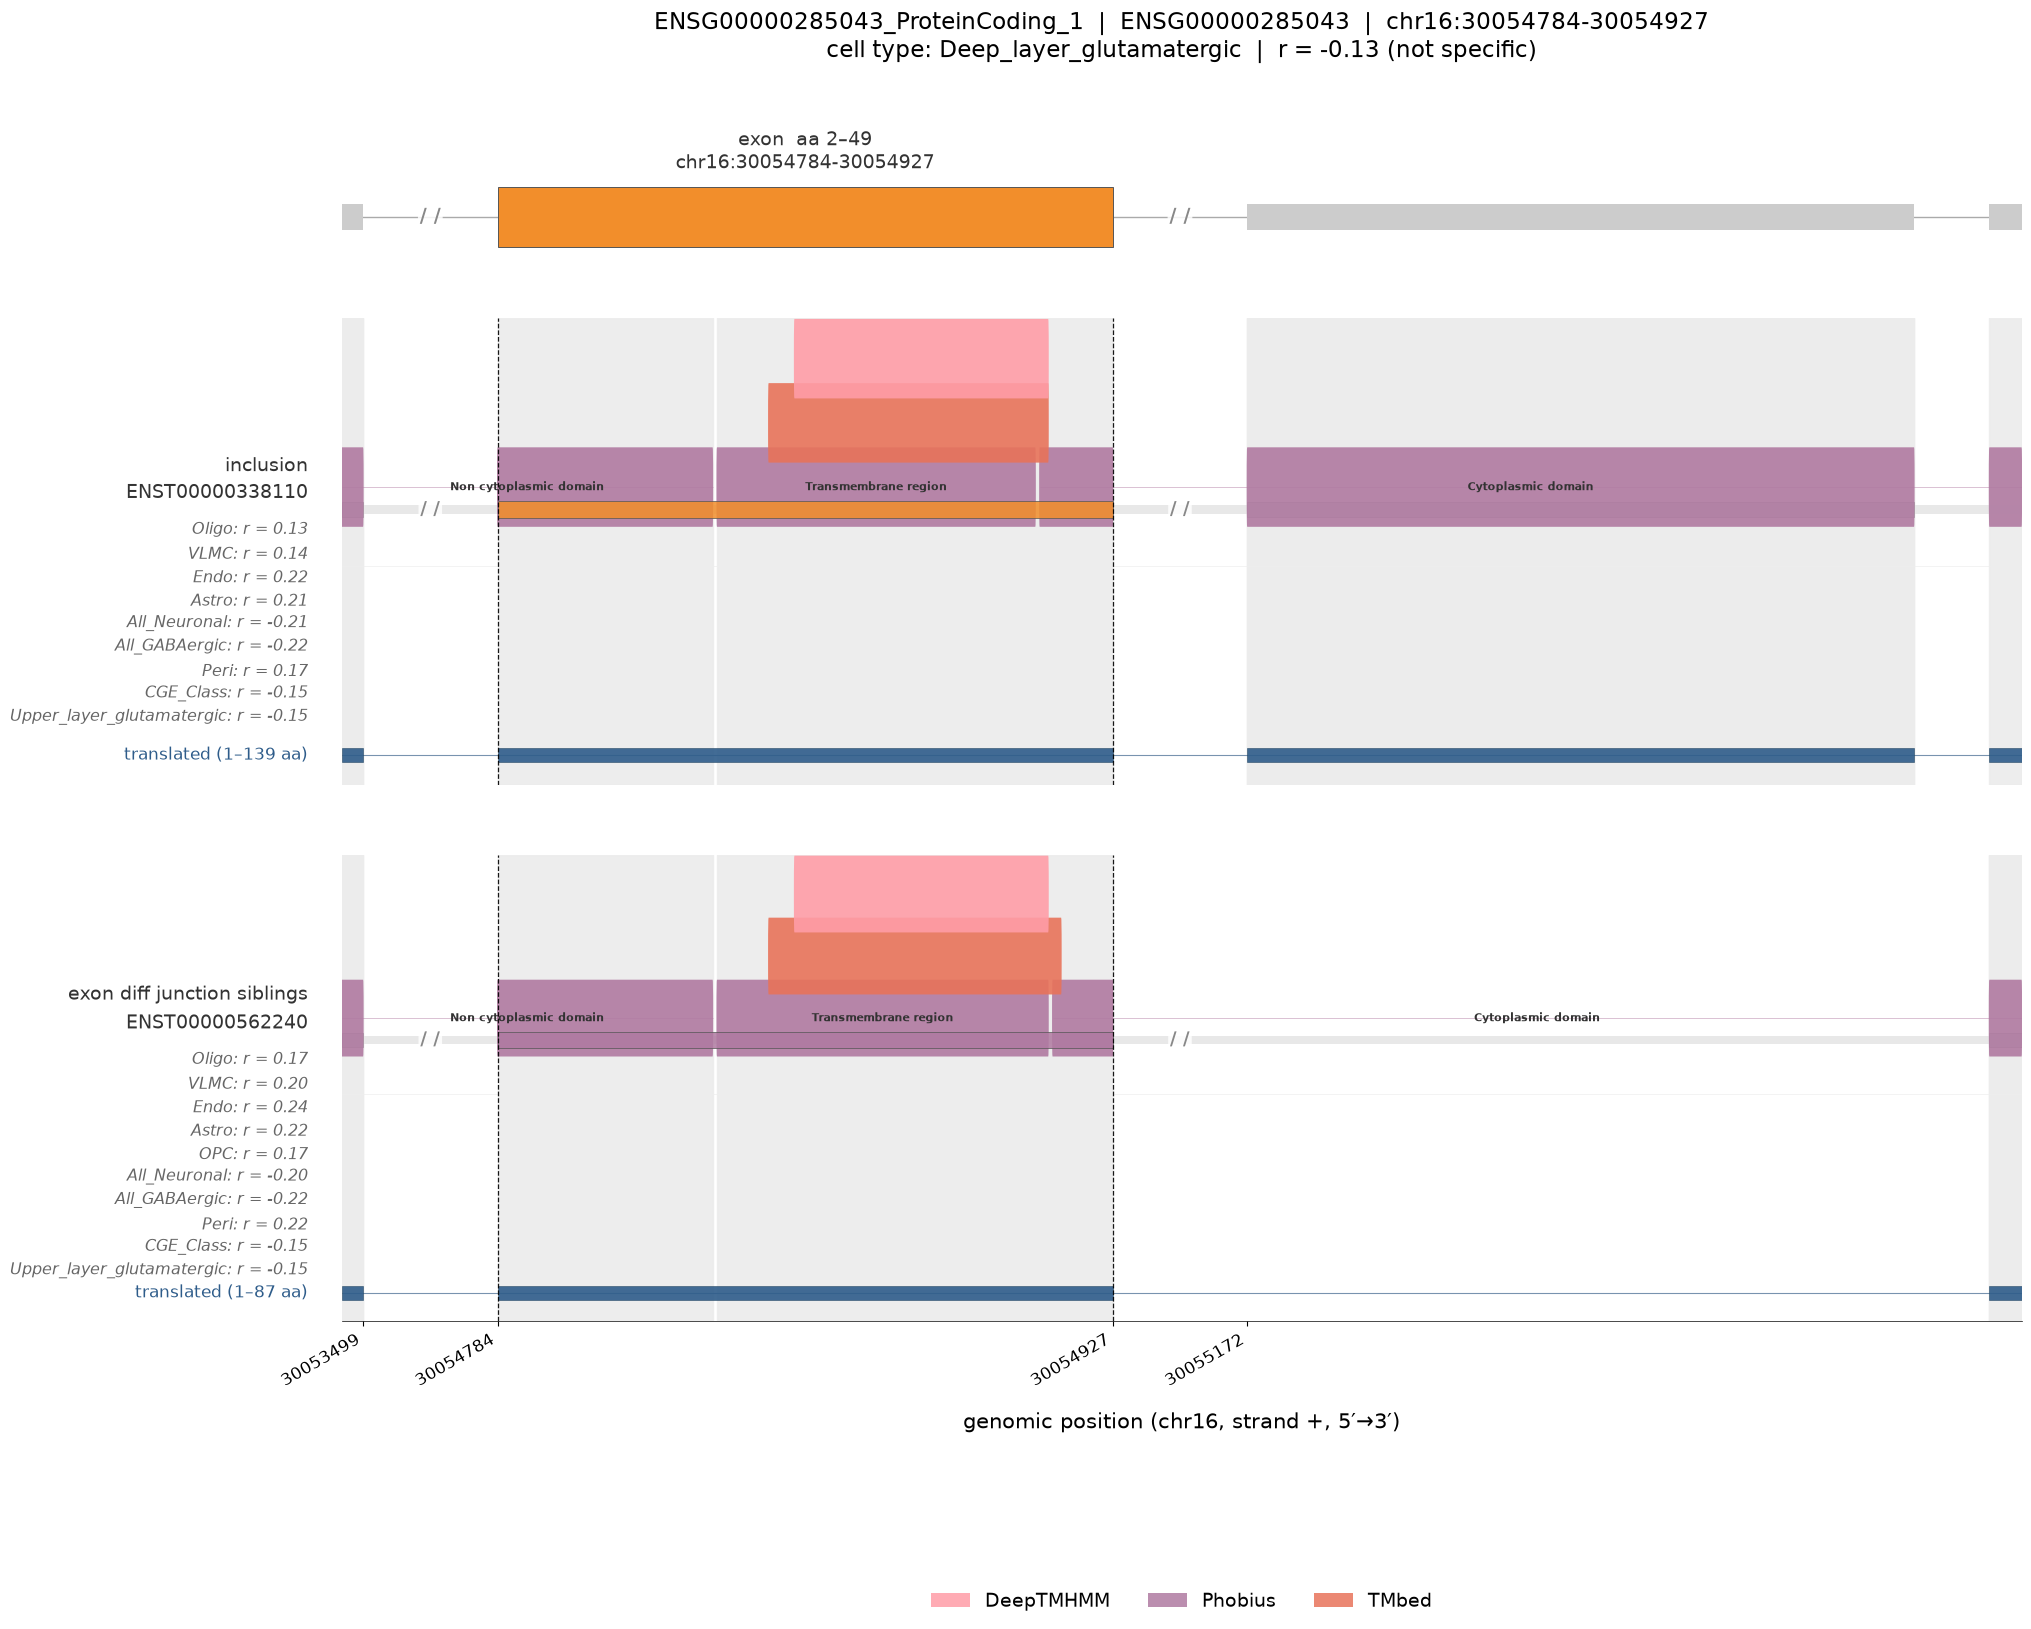

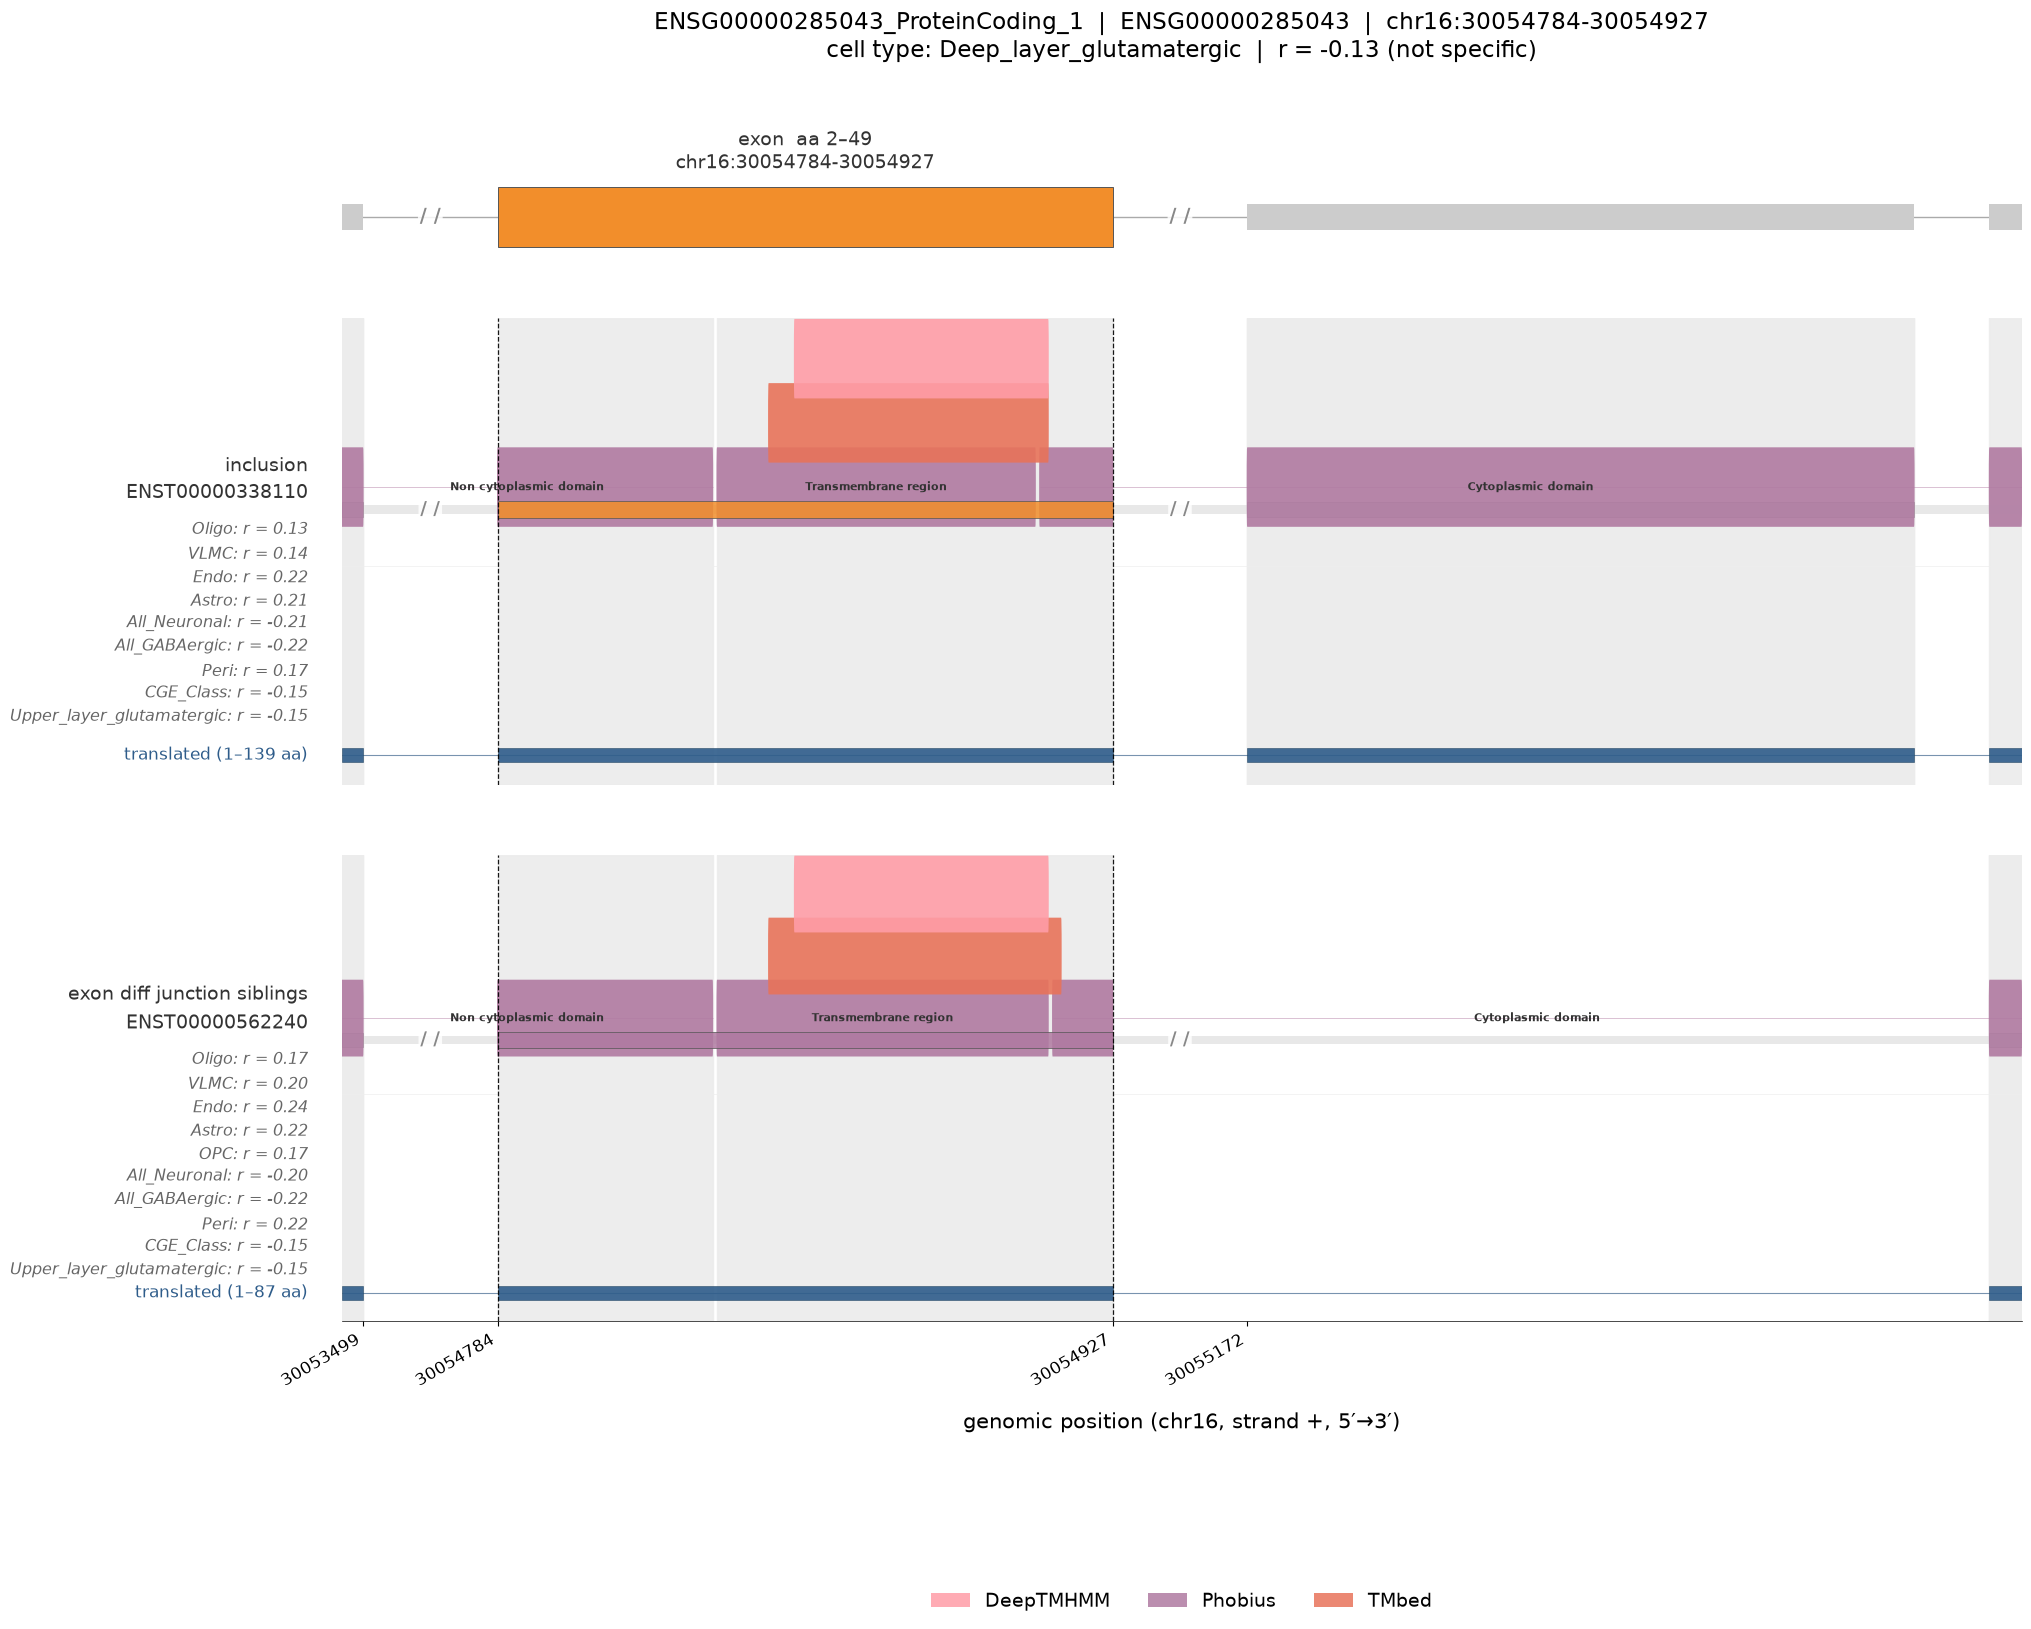

In [25]:
ct = "Deep_layer_glutamatergic"

ev = "ENSG00000146904_ProteinCoding_1"
ev = "ENSG00000056291_ProteinCoding_1"
ev = "ENSG00000285043_ProteinCoding_1"

plot_event_domains(ev, event_interproscan_map, signif_event_interproscan_map,
                   cds_by_transcript, ctype='Deep_layer_glutamatergic',
                   fontscale=2.5, figsize=(24, 16),
                   save_path=f"figures/interproscan/{ev}_{ct}.pdf", dpi=200)